## Import Libraries 

In [ ]:
import os
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import math

import torch
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm


# Paths
base_path = "/kaggle/input/shapes-dataset"
train_img_dir = os.path.join(base_path, "dataset_v2")
test_img_dir = os.path.join(base_path, "dataset_v2")

# CSV files
train_csv_path = os.path.join(base_path, "train_v2.csv")
test_csv_path = os.path.join(base_path, "test_v2.csv")

## Dataset Preprocessing

In [3]:
df = pd.read_csv(train_csv_path)
print(df.count())
df.head()

image_path    5000
label         5000
dtype: int64


,image_path,label
0,train_dataset_v2/img_0.png,"[('square', 'green')]"
1,train_dataset_v2/img_1.png,[]
2,train_dataset_v2/img_2.png,[]
3,train_dataset_v2/img_3.png,"[('square', 'red'), ('circle', 'blue'), ('tria..."
4,train_dataset_v2/img_4.png,[]


In [4]:
# Transform Dataframe
df['image_path'] = df['image_path'].apply(lambda x: os.path.join(train_img_dir, x))

# Safely convert string list-of-tuples to actual list-of-tuple
df['label'] = df['label'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x != '[]' else [])


In [5]:
class LabelEncoderDecoder:
    def __init__(self, shapes=None, colors=None):
        self.shapes = shapes if shapes else ['circle', 'square', 'triangle']
        self.colors = colors if colors else ['red', 'blue', 'green']
        
        self.pairs = [(s, c) for s in self.shapes for c in self.colors]
        self.pair_to_index = {pair: i for i, pair in enumerate(self.pairs)}
        self.index_to_pair = {i: pair for pair, i in self.pair_to_index.items()}
        self.vector_length = len(self.pairs)

    def encode(self, labels):
        encoded = np.zeros(self.vector_length, dtype=int)
        for label in labels:
            if isinstance(label, tuple) and label in self.pair_to_index:
                encoded[self.pair_to_index[label]] = 1
        return encoded

    def decode(self, encoded_label):
        decoded = []
        for i, value in enumerate(encoded_label):
            if value == 1 and i in self.index_to_pair:
                decoded.append(self.index_to_pair[i])
        return decoded

    def get_length(self):
        return len(self.shapes) * len(self.colors)
        
# Add encoded labels to dataframe.
# Shapes and colors can be dynamically loaded from a config file
# This will help in scalability without changing the Model architecture
labeler = LabelEncoderDecoder(shapes = ['circle', 'square', 'triangle'],
                              colors = ['red', 'blue', 'green'])
df['encoded_label'] = df['label'].apply(labeler.encode)
df.head()

,image_path,label,encoded_label
0,/kaggle/input/shapes-dataset/dataset_v2/train_...,"[(square, green)]","[0, 0, 0, 0, 0, 1, 0, 0, 0]"
1,/kaggle/input/shapes-dataset/dataset_v2/train_...,[],"[0, 0, 0, 0, 0, 0, 0, 0, 0]"
2,/kaggle/input/shapes-dataset/dataset_v2/train_...,[],"[0, 0, 0, 0, 0, 0, 0, 0, 0]"
3,/kaggle/input/shapes-dataset/dataset_v2/train_...,"[(square, red), (circle, blue), (triangle, gre...","[0, 1, 0, 1, 0, 1, 0, 0, 1]"
4,/kaggle/input/shapes-dataset/dataset_v2/train_...,[],"[0, 0, 0, 0, 0, 0, 0, 0, 0]"


## Exploratory Data Analysis


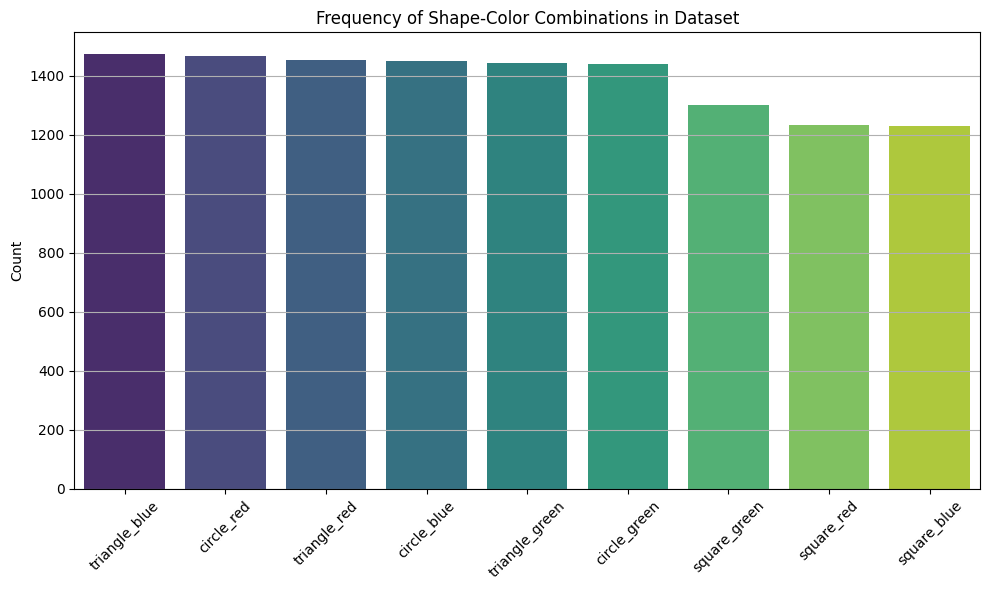

In [6]:
# Convert encoded labels to a DataFrame
encoded_df = pd.DataFrame(df['encoded_label'].to_list(), 
                          columns=['circle_red', 'circle_blue', 'circle_green', 
                                   'square_red', 'square_blue', 'square_green',
                                   'triangle_red', 'triangle_blue', 'triangle_green'])

# Sum each column to get counts
label_counts = encoded_df.sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title("Frequency of Shape-Color Combinations in Dataset")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

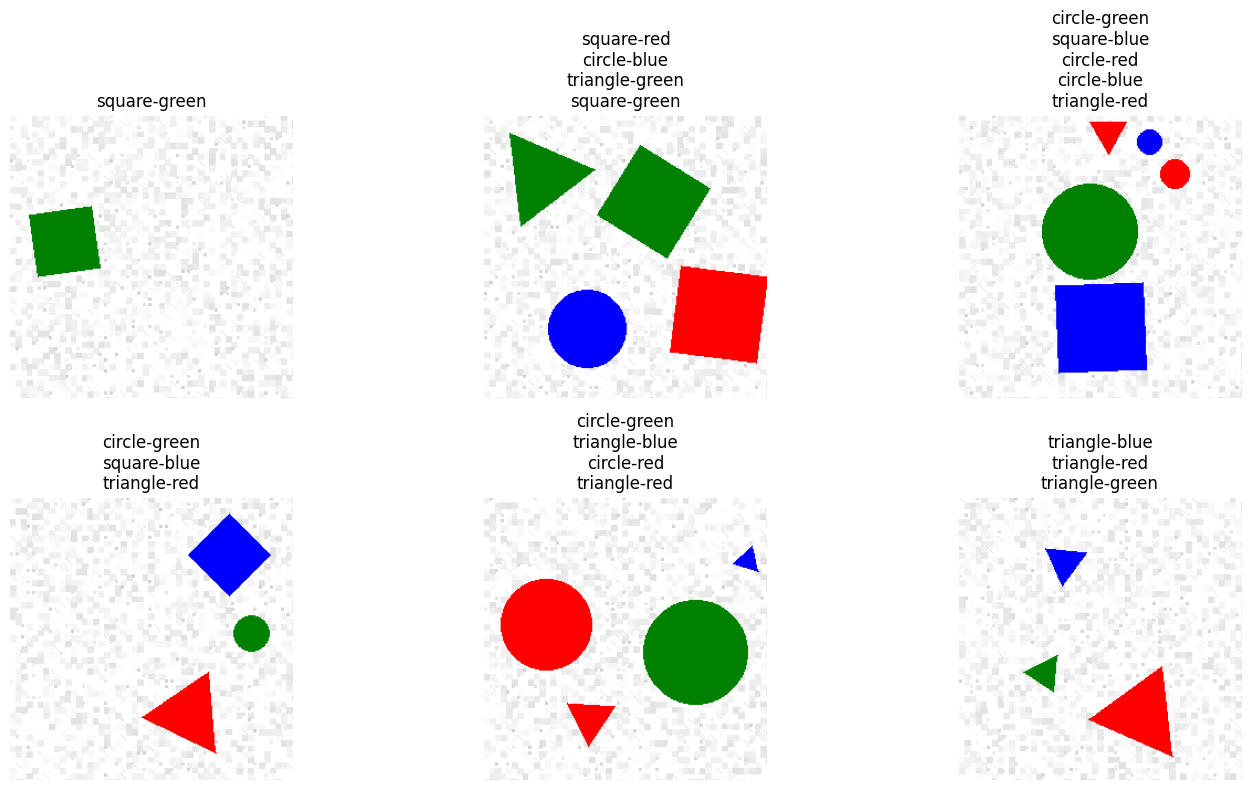

In [7]:
def show_sample_images(df, num_samples=6):
    # Take the first `num_samples` rows with non-empty labels
    sample_df = df[df['label'].apply(len) > 0].head(num_samples)

    # Dynamically calculate number of rows and columns
    cols = 3
    rows = math.ceil(num_samples / cols)

    plt.figure(figsize=(5 * cols, 4 * rows))
    for i, (img_path, labels) in enumerate(zip(sample_df['image_path'], sample_df['label'])):
        if isinstance(labels, str):
            labels = ast.literal_eval(labels)
        img = Image.open(img_path)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title("\n".join([f"{shape}-{color}" for shape, color in labels]))

    plt.tight_layout()
    plt.show()

# Visualize Training Dataset
show_sample_images(df)

## Dataset Split

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

class ShapesDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(row['encoded_label'], dtype=torch.float32)
        image_path = row['image_path']
        return img, label, image_path


# Dataset and split
dataset = ShapesDataset(df, transform=transform)
train_len = int(0.8 * len(dataset))
val_len = len(dataset) - train_len
train_set, val_set = random_split(dataset, [train_len, val_len])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32)

## Model Definition

In [9]:
class MultiLabelModel(nn.Module):
    def __init__(self, num_classes):
        super(MultiLabelModel, self).__init__()
        self.model = models.resnet18()
        self.model.load_state_dict(torch.load('/kaggle/input/resnet18/pytorch/default/1/resnet18-f37072fd.pth', weights_only=True))
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return torch.sigmoid(self.model(x))


## Train the model

In [23]:
NUM_EPOCHS = 8
LEARNING_RATE = 1e-4

# Initialize
model = MultiLabelModel(labeler.get_length()).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=False)

    for images, labels,_ in progress_bar:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Avg Loss: {total_loss/len(train_loader):.4f}")


Epoch [1/8], Avg Loss: 0.1896


Epoch [2/8], Avg Loss: 0.0586


Epoch [3/8], Avg Loss: 0.0383


Epoch [4/8], Avg Loss: 0.0272


Epoch [5/8], Avg Loss: 0.0210


Epoch [6/8], Avg Loss: 0.0169


Epoch [7/8], Avg Loss: 0.0140


Epoch [8/8], Avg Loss: 0.0109


## Save the model

In [24]:
# Save model weights
torch.save(model.state_dict(), 'multilabel_model_weights.pth')

# load saved model
LOAD_SAVED_MODEL = False
if LOAD_SAVED_MODEL:
    model_loaded = MultiLabelModel(num_classes=labeler.get_length())
    model_loaded.load_state_dict(torch.load('multilabel_model_weights.pth', map_location=device))
    model_loaded.to(device)
    model_loaded.eval()  # inference mode
    model = model_loaded

## Evaluation

In [25]:
def jaccard_similarity(true_labels, pred_labels):
    '''
        Function to compute Jaccard similarity for a pair of predicted and true labels
    '''
    # Convert the labels into sets of tuples (shape, color)
    true_set = set(true_labels)
    pred_set = set(pred_labels)

    if not true_set and not pred_set:
        return 1.0  # Treat empty prediction and label as perfect match
    intersection = len(true_set.intersection(pred_set))
    union = len(true_set.union(pred_set))    
    return intersection / union if union != 0 else 0.0


def evaluate_model_jaccard_and_get_wrong_predictions(model, data_loader, labeler, device):
    '''
        Function to evaluate the model on a given data loader using Jaccard similarity and return wrong predictions
    '''
    # Collect predictions and ground truth labels
    all_predictions = []
    all_ground_truth = []
    wrong_predictions = []

    model.eval()
    with torch.no_grad():
        for i, (images, labels, image_paths) in enumerate(data_loader):
            images, labels = images.to(device), labels.to(device)

            # Get predictions
            outputs = model(images)
            preds = (outputs > 0.5).cpu().numpy()  # Get binary predictions (for each label)

            for pred, true_label, img_path  in zip(preds, labels, image_paths):
                predicted_labels = labeler.decode(pred) 
                true_labels = labeler.decode(true_label.cpu().numpy())

                all_predictions.append(predicted_labels)
                all_ground_truth.append(true_labels)

                # store the wrong prediction
                if set(predicted_labels) != set(true_labels):
                    wrong_predictions.append({
                        'image_path': img_path,
                        'ground_truth': true_labels,
                        'predicted': predicted_labels
                    })
    
    # Calculate average Jaccard similarity across the dataset
    jaccard_scores = [jaccard_similarity(gt, pred) for gt, pred in zip(all_ground_truth, all_predictions)]
    average_jaccard = np.mean(jaccard_scores)
    
    return average_jaccard, wrong_predictions, all_predictions

# Usage on the validation set
average_jaccard, wrong_predictions, all_predictions = evaluate_model_jaccard_and_get_wrong_predictions(model, val_loader, labeler, device)
print(f"Average Jaccard Similarity on Validation Data: {average_jaccard:.4f}")

# Visualize first 5 wrong predictions if any.
print(f"Number of Wrong Predictions: {len(wrong_predictions)}")
for i, wrong_pred in enumerate(wrong_predictions[:5]):  
    print(f"Wrong Prediction {i+1}:")
    print(f"  Ground Truth: {wrong_pred['ground_truth']}")
    print(f"  Predicted: {wrong_pred['predicted']}")
    print(f"  Ground Truth: {wrong_pred['image_path']}")
    print()
    visualize = True
    if visualize == True:
        img = Image.open(wrong_pred['image_path'])
        plt.imshow(img)
        plt.axis('off')
        plt.show()

Average Jaccard Similarity on Validation Data: 1.0000
Number of Wrong Predictions: 0


**Average Jaccard Similarity on held out Validation Data: 100.00%** 

**Inference** : Every prediction exactly matched the ground truth. \
**Note** :These results are achieved due to the presense of synthetic dataset and a simpler classification task. \
I have added the visualization for wrong resutl prediction, in-case if you underfit/overfit the model this would come handy. 

## Prediction on Test data

In [30]:
# Prediction on Test data
model.eval()
predictions = []
image_ids = []

# Read the test CSV
test_df = pd.read_csv(test_csv_path)
test_df['image_path'] = test_df['image_path'].apply(lambda x: os.path.join(test_img_dir, x))

count = 0
with torch.no_grad():
    for _, row in test_df.iterrows():
        img = Image.open(row['image_path']).convert('RGB')
        img = transform(img).unsqueeze(0).to(device)

        output = model(img)
        preds = (output > 0.5).cpu().numpy()[0]  # Get binary predictions
        predictions.append(preds)
        image_ids.append(row['image_path'])

# Prepare the submission dataframe
submission_df = pd.DataFrame({
    'image_path': image_ids,
    'label': predictions
})

# Decode back results
submission_df['label'] = submission_df['label'].apply(labeler.decode).apply(lambda x: str(x))
submission_comp_df = submission_df.copy()

# Format path
submission_df['image_path'] = submission_df['image_path'].apply(lambda x: x.replace('/kaggle/input/shapes-dataset/dataset_v2/', ''))

# Save predicted results
submission_df.to_csv("submission.csv", index=False)


## Visualize Predicted Results

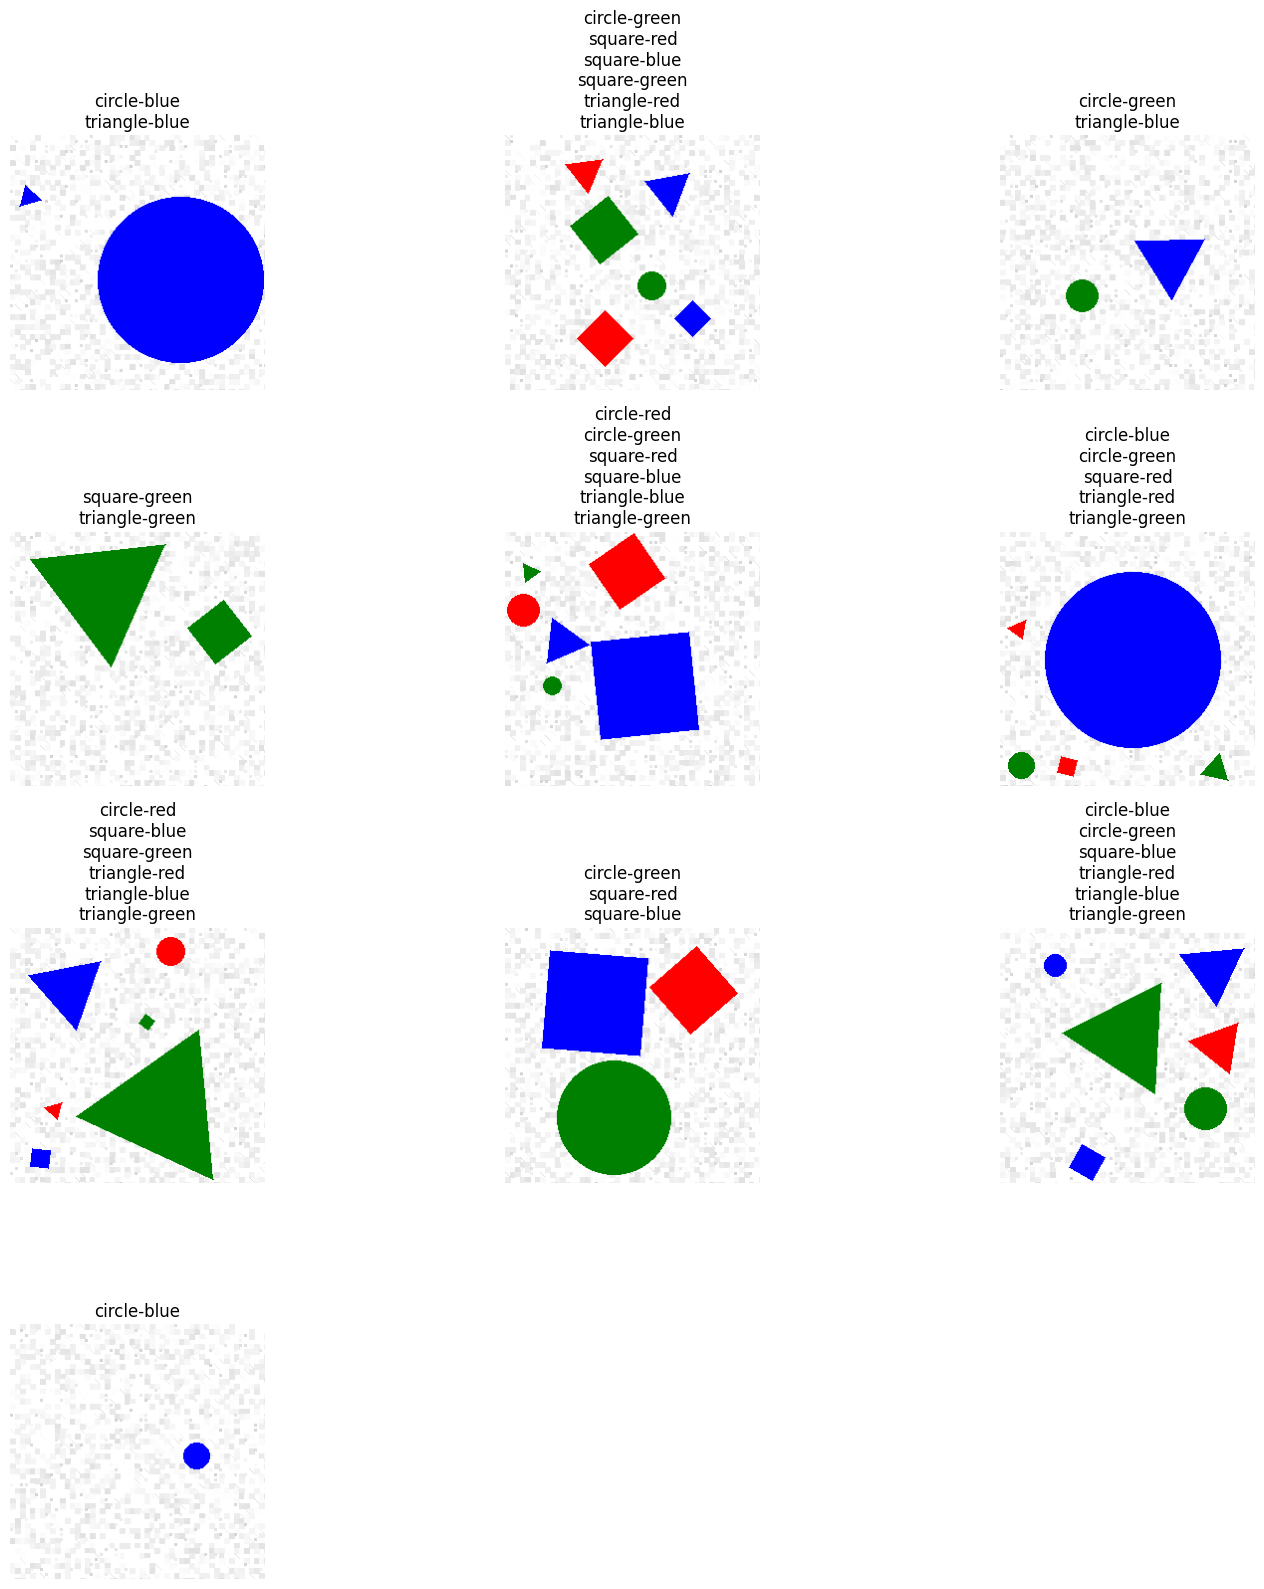

In [32]:
# Display predicted results on test data
show_sample_images(submission_comp_df, num_samples=10)